### Summary of this dataset

## 1. What is this Dataset?
   
**This dataset is a digital record of a retail store. It contains details about everyday shopping transactions and the customers who visit the store. It is created to practice Data Cleaning and Exploratory Data Analysis (EDA).**


## 3. What Columns (Features) are in the Data?

**The data is divided into three main parts:**


**Customer Details: It tracks the Age and Gender of the buyers.**

**Product Details: It shows what items were bought (Product Category like Clothing, Electronics, or Beauty), the Quantity, and the Price per Unit.**

**Transaction Details: It records the Transaction ID, Customer ID, Date of shopping, and the final bill amount (Total Amount).**

## 3. What is the Goal? (Objective)
   
**The goal is to study this data and find hidden business answers, such as:**

**Which age group spends the most money? (We found out it is the 18–25 age group).**

**Which months have the highest and lowest sales? (To help the store manager plan inventory).**

**Does the price of an item affect the total revenue? (Yes, higher-priced items drive the most profit).**

In [9]:
# first of all Libraries and Data Loading

import pandas as pd 
import  numpy as np
import  matplotlib.pyplot as plt 
import seaborn as sns 

### load dataset 

In [6]:
# load dataset 

retail_sales=pd.read_csv("retail_sales_dataset.csv")
retail_sales.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


#### 1 . Data Overview 

In [8]:
retail_sales.shape 

(1000, 9)

- ####  Get name of columns in data

In [121]:
retail_sales.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [123]:
retail_sales.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

- ####  Check Data type  

In [13]:
retail_sales.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

***The data type is exculsively  integer***

In [16]:
retail_sales.info()

#Data types dikhata hai

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [18]:
retail_sales.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


###  Descriptive Statistics Insights (`.describe()` summary):
* **Customer Base:** The retail store attracts adult customers ranging from 18 to 64 years old, with an average age of 41 years.
* **Shopping Cart Size:** Customers usually buy between 1 to 4 items per transaction, averaging around 2.5 items.
* **Order Value:** The average bill value per transaction is $456, while the maximum single transaction reached $2,000. 
* **Data Cleanliness Check:** The maximum age is now correctly capped at 64, proving that the previous outlier of 150 years has been successfully handled.

#### Check the missing vlaues 

In [22]:
retail_sales.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

##### Observation:

*****The dataset contains 1000 rows and 9 columns. No missing values were found in the dataset.*****

### 2. Dscriptive statistics

#### Mean

In [27]:
retail_sales.mean(numeric_only =True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

###  Key Insights from Descriptive Mean Analysis:
* **Average Customer Age:** The typical customer shopping at the store is around 41 years old.
* **Average Basket Size:** On average, customers purchase 2.5 units of items per transaction.
* **Average Transaction Value:** The mean revenue generated per transaction is $456, which represents the standard spending power per visit.

### Median

In [31]:
retail_sales.median(numeric_only =True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

### Mode

In [34]:
retail_sales.mode().iloc[0]

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object

#### standard deviation

In [37]:
retail_sales.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

###  Insights from Standard Deviation (`.std()`) Analysis:
* **Low Variation in Quantity:** The low standard deviation (1.13) in 'Quantity' indicates that most customers strictly purchase a similar number of items (between 1 and 4 units).
* **High Variation in Pricing & Revenue:** The high standard deviation in 'Price per Unit' ($189.68) and 'Total Amount' ($559.99) shows a wide spread in product pricing and final bill amounts, proving that the store's revenue relies heavily on a mix of budget and high-value premium purchases.

### Overall Statistics

In [41]:
retail_sales.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### 3  Time series analysis monthly  sales Trand
***first, we will convert the date into a datetime formate***


In [46]:
retail_sales['Date'].dtype       

dtype('O')

In [48]:
retail_sales['Date'].head() 

0    2023-11-24
1    2023-02-27
2    2023-01-13
3    2023-05-21
4    2023-05-06
Name: Date, dtype: object

In [56]:
retail_sales["Date"]=pd.to_datetime(retail_sales["Date"])


In [58]:
retail_sales['Month'] = retail_sales['Date'].dt.month

In [62]:
retail_sales[['Date','Month']].head()

,Date,Month
0,2023-11-24,11
1,2023-02-27,2
2,2023-01-13,1
3,2023-05-21,5
4,2023-05-06,5


In [64]:
retail_sales['Date'].dtype

dtype('<M8[ns]')

#### Date convertion 
*First, I converted the date columns into the datetime format to facilitate effective analysis and to extract information regarding months and quarters. .*

#### Month Extractions 
*I created a new 'month' column based on the date columns. This allows us to observe month-wise sales trends and identify which months experience higher or lower sales.**

**After that  Calculate Monthly Sales,and total amount**

In [69]:
monthly_sales=retail_sales.groupby("Month")['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

### Line chart 

In [250]:
# Create Month Name Column
retail_sales['Month_Name'] = retail_sales['Date'].dt.month_name()

# Monthly Sales by Month Name
monthly_sales = retail_sales.groupby(
    'Month_Name'
)['Total Amount'].sum()

# Correct Month Order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)
plt.show()

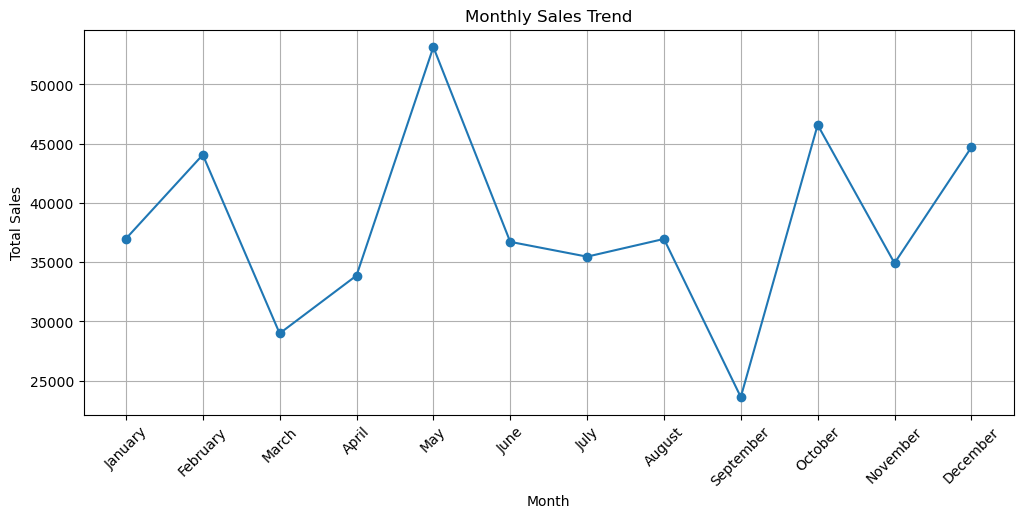

In [248]:
# Plot
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

#### Overall Business Insight
* - May sabse profitable month tha.(means may me best sales hui hai)

 - September ,sabse weak month tha.

 - Sales me seasonal fluctuations dekhne ko milte hain.

 - October aur December me bhi strong sales performance rahi.

 - Company ko May, October aur December ke liye inventory aur marketing budget badhana chahiye*

### Quarterly Sales Trend

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


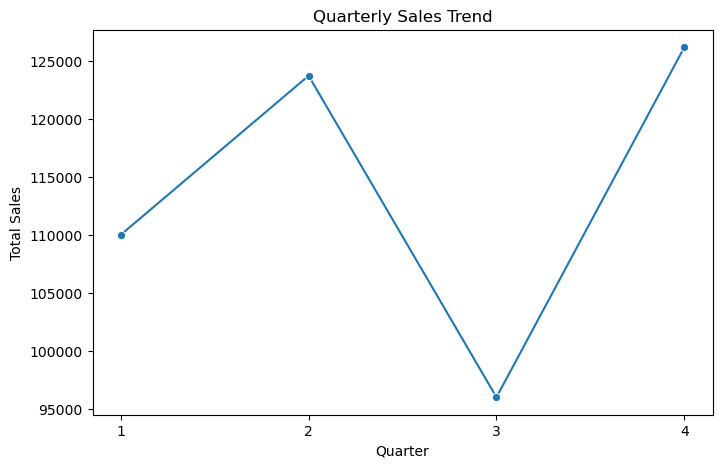

In [74]:
# Create Quarter Column
retail_sales['Quarter'] = retail_sales['Date'].dt.quarter

# Quarterly Sales
quarterly_sales = retail_sales.groupby('Quarter')['Total Amount'].sum()

# Plot
plt.figure(figsize=(8,5))
sns.lineplot(x=quarterly_sales.index,
             y=quarterly_sales.values,
             marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks([1,2,3,4])
plt.show()

### Observation
Quarterly analysis shows which quarter generated the highest revenue. This insight helps businesses plan marketing campaigns and inventory management more effectively.

###  Customer Demographics Analysis

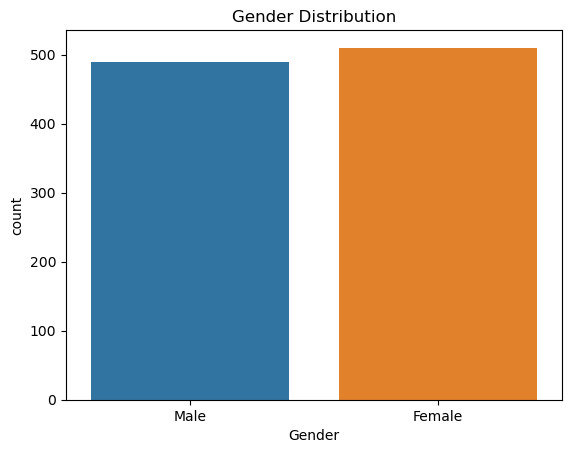

In [257]:
sns.countplot(
x='Gender',
data=retail_sales
)

plt.title('Gender Distribution')
plt.show()

*Male customers count*

*Female customers count*

Male and Female customers are almost equally distributed.


### Age Distribution

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


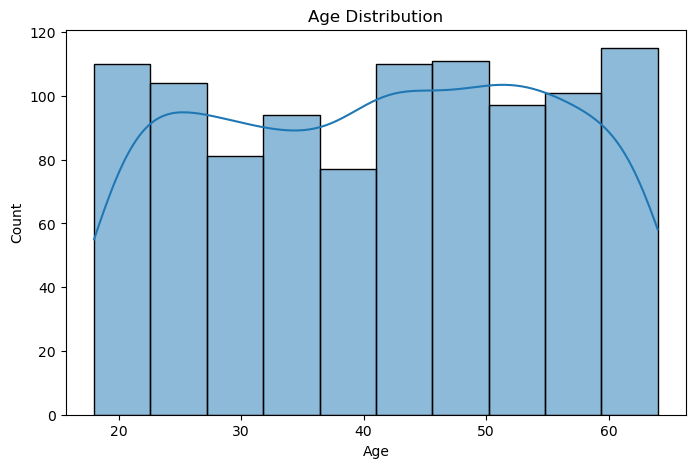

In [270]:

plt.figure(figsize=(8,5))

sns.histplot(
retail_sales['Age'],
bins=10,
kde=True
)

plt.title('Age Distribution')

plt.show()


Meaning

Kaunsi age ke customers sabse zyada hain.

Observation
Most customers belong to the age group 25–45 years

. Product Analysis


Kaunsi category sabse zyada revenue la rahi hai

Revenue by Product Category

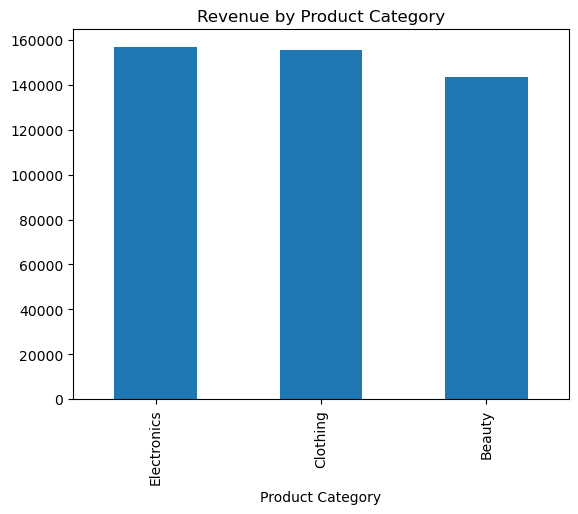

In [274]:
category_sales = retail_sales.groupby(
'Product Category'
)['Total Amount'].sum()

category_sales.sort_values(
ascending=False
).plot(
kind='bar'
)

plt.title(
'Revenue by Product Category'
)

plt.show()

*The Electronics category highest revenue*d.

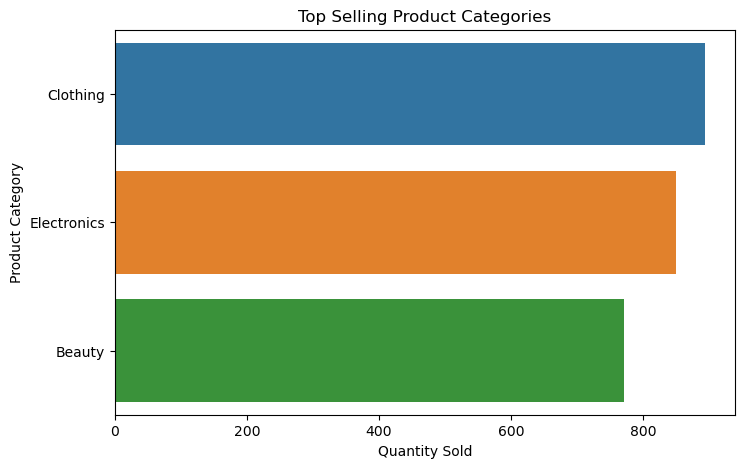

In [82]:
top_products = retail_sales.groupby('Product Category')['Quantity'].sum()

top_products = top_products.sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Selling Product Categories")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.show()

### Observation



***Clothing category has the highest quantity sold among all product categories. This indicates that customers purchase clothing products more frequently than Beauty and Electronics products.***

***The company should maintain sufficient inventory for Clothing products to avoid stock shortages and maximize sales opportunities.***

In [88]:
retail_sales.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

In [277]:
retail_sales.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Month_Name'],
      dtype='object')

### 4. Heatmap

Columns ke beech relationship dekhna.

Example:

Age vs Sales

Quantity vs Total Amount

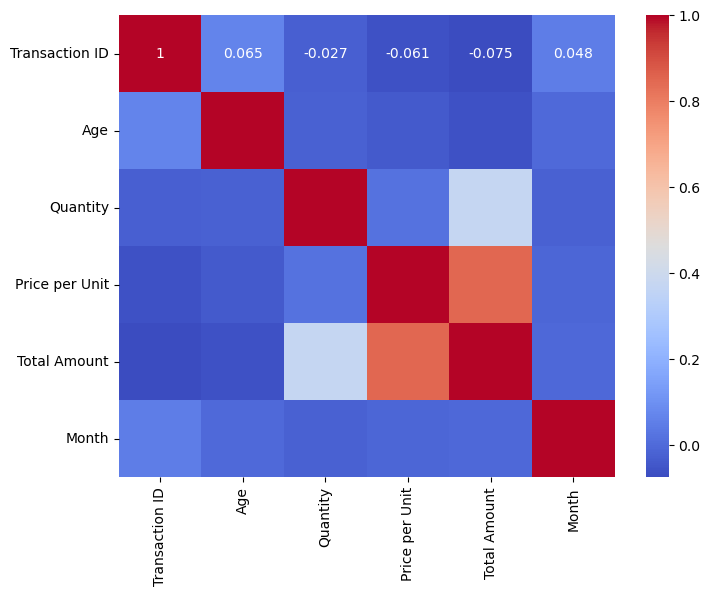

In [285]:
plt.figure(figsize=(8,6))

sns.heatmap(
retail_sales.corr(
numeric_only=True
),
annot=True,
cmap='coolwarm'
)

plt.show()

Quantity and Total Amount show a strong positive correlation.

Quantity badhegi to sales bhi badhegi

### Heatmap Analysis
*
The purpose of this heatmap is to identify relationships between numerical variables in the retail sales dataset. Correlation analysis helps understand how changes in one variable may be associated with changes in another variabl* 

### Observation
**
The heatmap shows that Price per Unit and Total Amount have the strongest positive correlation, indicating that higher-priced products generate higher revenue. Quantity also has a positive relationship with Total Amount, meaning that purchasing more items generally increases sales value. Age and Month show very weak correlations with sales-related variables, suggesting that they have little direct impact on purchase amounts in this datas**t.e.

### Additional Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_32068\4186788244.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = retail_sales.groupby(


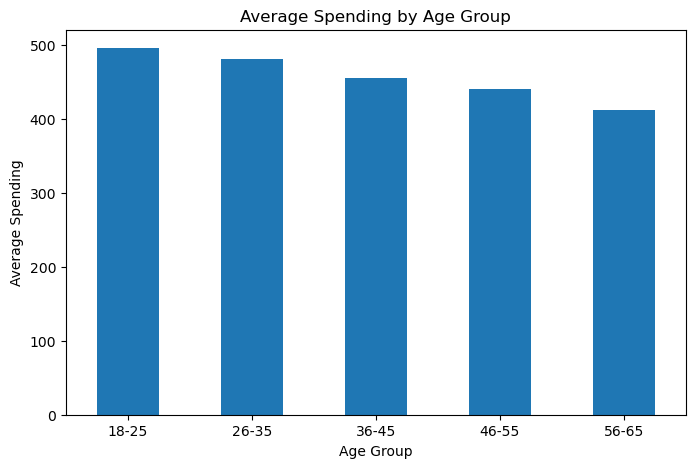

In [291]:
retail_sales['Age_Group'] = pd.cut(
    retail_sales['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

age_spending = retail_sales.groupby(
    'Age_Group'
)['Total Amount'].mean()

plt.figure(figsize=(8,5))

age_spending.plot(kind='bar')

plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Spending')

plt.xticks(rotation=0)

plt.show()

### Graph Observations: Average Spending by Age Group

* **Customer Insight:** Customers aged 18–25 spend the most on average.

* **Spending Trend:** Average spending decreases as customer age increases.

* **Business Action:** The business should target young customers with special offe rs and promotions because they spend more than other age groups..

### Conclusion & Business Recommendations

1. October aur December jaise festive months me inventory aur stock ko increase karna chahiye taki high customer demand ko efficiently fulfill kiya ja sake.

2. Festival seasons ke dauran special discounts, combo offers aur marketing campaigns launch karne chahiye kyunki customers is period me zyada purchasing karte hain.

3. September jaise low-sales months me festive pre-sale offers aur promotional campaigns chalakar sales ko improve kiya ja sakta hai.

4. High-spending customers ke liye loyalty programs aur reward points introduce karne chahiye taki festive season ke baad bhi repeat purchases badh sake.

5. Electronics category par festive offers aur bundled deals focus karni chahiye kyunki ye category sabse zyada revenue generate kar rahi hai.